# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import comet_ml
import json

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.calibration import CalibrationDisplay

from xgboost import XGBClassifier

from scipy import stats

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.selection_scripts import create_best_selection_path, find_optimal_cut_point
from analysis_scripts.estimate_scripts import signal_estimates
from analysis_scripts.draw_scripts import draw_feature_distribution, draw_roc

CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load preprocessed data

In [2]:
train_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_train_2.csv').drop('Unnamed: 0', axis=1)
test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_test_1.csv').drop('Unnamed: 0', axis=1)

assert not train_df.isna().sum().sum(), 'Train, data containes NaNs!!'
assert not test_df.isna().sum().sum(), 'Test, data containes NaNs!!'

# Prepare Data

In [3]:
# Comet logger
# experiment = comet_ml.Experiment(
#     project_name="SPD ML",
#     workspace="artem-smirnov",
#     api_key="yyKk8vacVuy8dbttSCIgF2iQO"
# )

x = train_df.drop(['tag'], axis=1).copy()
y = train_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

x_train_full, x_val_full, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=True, stratify=y, random_state=CFG.seed)

features_list = CFG.feature_set_3
# features_list = CFG.feature_cut_based_sel

x_train = x_train_full[features_list].copy()
x_val = x_val_full[features_list].copy()

x_test_full = test_df.drop(['tag'], axis=1).copy()

x_test = test_df[features_list].copy()
y_test = test_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()


try:
    experiment.set_name('feature_set_1, params_xgboost_1')
    formatted_text = json.dumps({"feature_names": features_list}, indent=2)
    experiment.log_text(text=formatted_text)
except NameError:
    pass

In [4]:
# Feature encoding
if features_list == CFG.feature_set_1:
    cols_to_encode = [
        'highest_pt_daughter', 'highest_momentum_daughter', 'highest_OA_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_2:
    cols_to_encode = [
        'highest_momentum_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_3:
    cols_to_encode = ['highest_momentum_daughter']

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, dtype=int), cols_to_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.fit(x_train)
x_train_encoded = preprocessor.transform(x_train)
x_val_encoded = preprocessor.transform(x_val)
x_test_encoded = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()

x_train = pd.DataFrame(x_train_encoded, columns=feature_names, index=x_train.index)
x_val = pd.DataFrame(x_val_encoded, columns=feature_names, index=x_val.index)
x_test = pd.DataFrame(x_test_encoded, columns=feature_names, index=x_test.index)


# Drop excluded columns
if features_list == CFG.feature_set_2:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
        'highest_eta_daughter_eta_pip', 'highest_dca_PV_daughter_dist_pip_PV_xy',
        'highest_dca_Lc_daughter_dist_p_Lc_xy',
    ]

    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)
    
elif features_list == CFG.feature_set_3:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
    ]
    
    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)

In [5]:
# x_train.to_csv('/home/ome123/Загрузки/x_train.csv')
# y_train.to_csv('/home/ome123/Загрузки/y_train.csv')

In [6]:
for feature in features_list:
    
    if feature in CFG.cols_to_log_transform:
        pass
        # x_train[feature + '_log'] = np.log1p(x_train[feature])
        # x_val[feature + '_log'] = np.log1p(x_val[feature])
        # x_test[feature + '_log'] = np.log1p(x_test[feature])
    
    if feature in CFG.continual_features:
        pass
        # x_train[feature + '_pct'] = x_train[feature].rank(pct=True)
        # x_val[feature + '_pct'] = x_val[feature].rank(pct=True)
        # x_test[feature + '_pct'] = x_test[feature].rank(pct=True)
    
        # x_train[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_val[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_test[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)

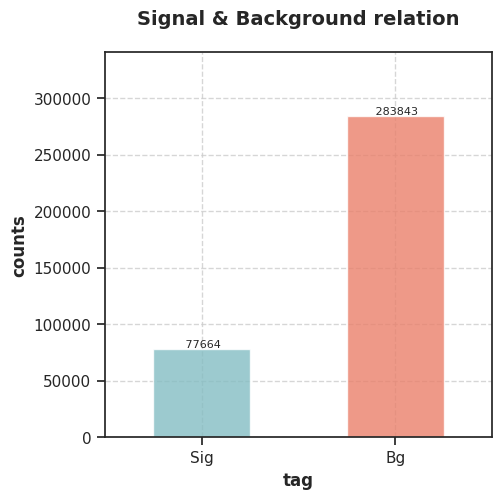

<Figure size 640x480 with 0 Axes>

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

temp_df = pd.concat([x_train, y_train], axis=1)
temp_df['tag'] = temp_df['tag'].map({1: 'Sig', 0: 'Bg'})

sns.countplot(
    data = temp_df,
    x='tag',
    hue='tag',
    width=0.5,
    alpha=0.8,
    order=['Sig', 'Bg'],
    palette={'Sig': '#7AC5CD', 'Bg': '#FF7256'},
    ax=ax
)

max_value = temp_df['tag'].value_counts().max()
ax.set_ylim(0, max_value * 1.2)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + height * 0.001,
                f'{height: .0f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Signal & Background relation", fontsize=14, fontweight='bold', pad=20)

ax.set_xlabel("tag", fontweight='bold')
ax.set_ylabel("counts", fontweight='bold')

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

ax.grid(True, alpha=0.8, linestyle='--')

plt.show()
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/sig_bg_relation_train.pdf')

# XGBoost

### Feature Importance

#### XGBoost FE

/tmp/ipykernel_36751/3760064015.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


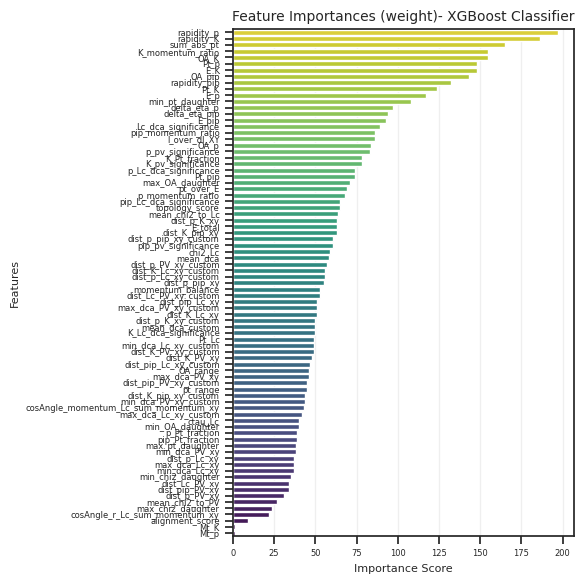

/tmp/ipykernel_36751/3760064015.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


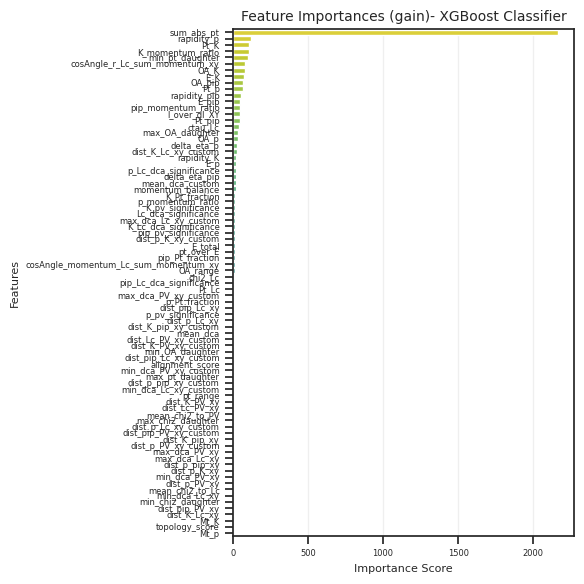

/tmp/ipykernel_36751/3760064015.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


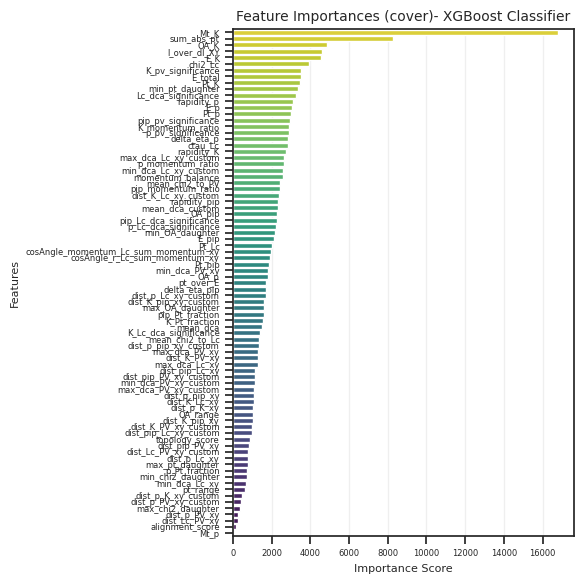

In [6]:
from xgboost import XGBClassifier


# params = CFG.params_xgboost_1
params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256, 
})

model = XGBClassifier(**params)

model.fit(x_train, y_train)

for importance_type in ['weight', 'gain', 'cover']:
    
    importance_scores = model.get_booster().get_score(importance_type=importance_type)

    feature_df = pd.DataFrame({
        'feature': list(importance_scores.keys()),
        'importance': list(importance_scores.values())
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(6, 6))

    sns.barplot(
        data=feature_df,
        x='importance',
        y='feature',
        palette='viridis_r',
        orient='h'
    )

    plt.title(f'Feature Importances ({importance_type})- XGBoost Classifier', fontsize=10)
    plt.xlabel('Importance Score', fontsize=8)
    plt.ylabel('Features', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=6)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/XGBoost_FE_{importance_type}.pdf', bbox_inches='tight')
    plt.show()

#### permutation_importance

/tmp/ipykernel_36751/2448695069.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


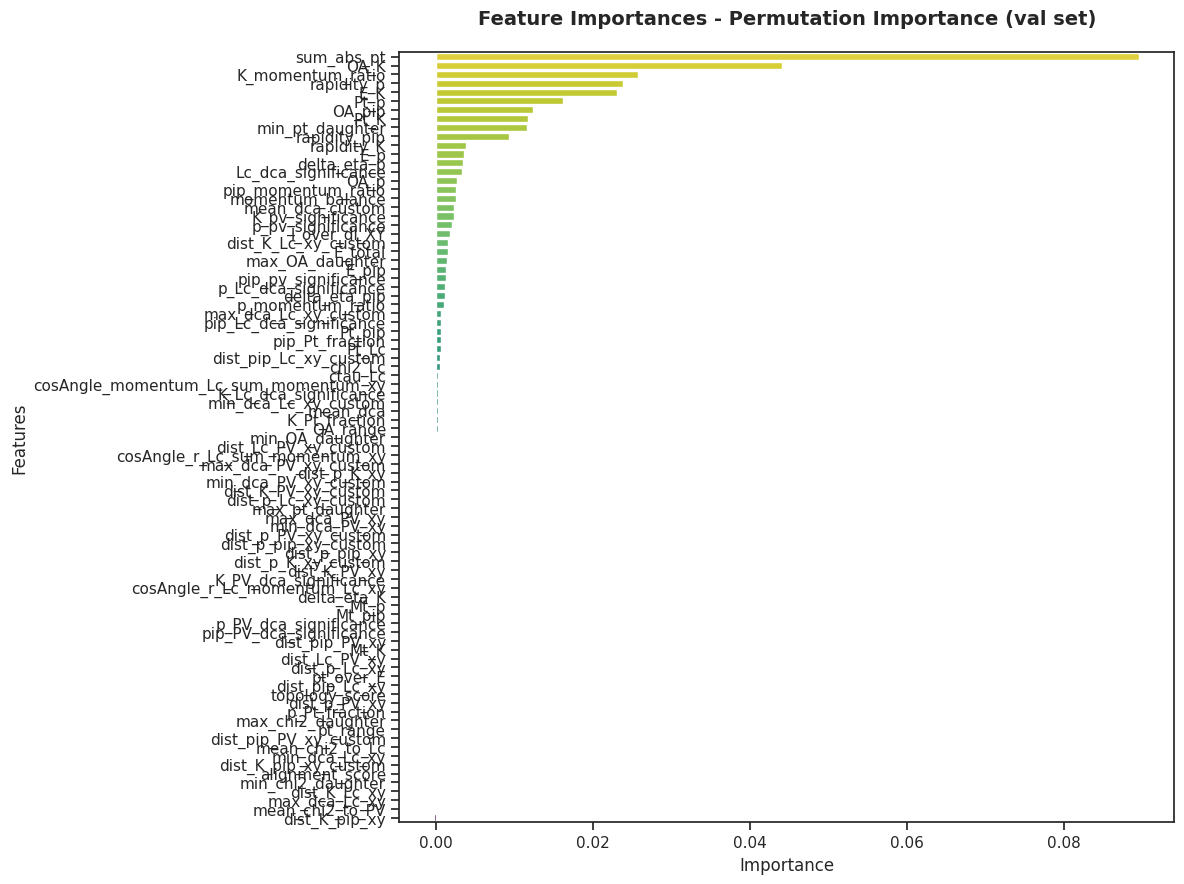

In [7]:
from sklearn.inspection import permutation_importance


# params = CFG.params_xgboost_1
params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256, 
    # 'scale_pos_weight': len(y_train[y_train == 0]) / len(y_train[y_train == 1])
})

model = XGBClassifier(**params)

model.fit(x_train, y_train)

# perm_importance = permutation_importance(model, x_train, y_train, n_repeats=10, random_state=CFG.seed)
perm_importance = permutation_importance(model, x_val, y_val, n_repeats=10, random_state=CFG.seed)

perm_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=perm_df,
    x='importance',
    y='feature', 
    capsize=0.2,
    palette='viridis_r',
    ax=ax
)
plt.title('Feature Importances - Permutation Importance (val set)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/XGBoost_FE_permutations_val.pdf', bbox_inches='tight')
plt.show()

#### shap

In [8]:
import shap

params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256, 
})

model = XGBClassifier(**params)
model.fit(x_train, y_train)

explainer = shap.Explainer(model)
shap_values = explainer(x_train)
explanation = explainer(x_train)

In [9]:
# fig, ax = plt.subplots(figsize=(5, 40))
# shap.plots.bar(shap_values, max_display=300, ax=ax)
shap_importance = pd.DataFrame({
    'feature': x_train.columns,
    'shap_mean_abs': np.abs(shap_values.values).mean(axis=0)
}).sort_values('shap_mean_abs', ascending=False)

for row in shap_importance.itertuples():
    print(f'{row.feature:<40}:  {row.shap_mean_abs}')

sum_abs_pt                              :  1.5497649908065796
OA_K                                    :  0.9095463752746582
K_momentum_ratio                        :  0.7077478170394897
rapidity_p                              :  0.6834211945533752
Pt_p                                    :  0.6325411200523376
E_K                                     :  0.5797961354255676
min_pt_daughter                         :  0.38860446214675903
Pt_K                                    :  0.3677736818790436
E_p                                     :  0.2765522599220276
OA_pip                                  :  0.27252018451690674
rapidity_pip                            :  0.22621698677539825
rapidity_K                              :  0.20811504125595093
l_over_dl_XY                            :  0.1603556126356125
delta_eta_p                             :  0.15863002836704254
p_Lc_dca_significance                   :  0.1395040899515152
delta_eta_pip                           :  0.13240791857242584
Lc

In [30]:
clustering = shap.utils.hclust(x_train, y_train)

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/shap/utils/_clustering.py:170: UserWarning: No/low signal found from feature 1 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
2402it [06:45,  5.68it/s]                          


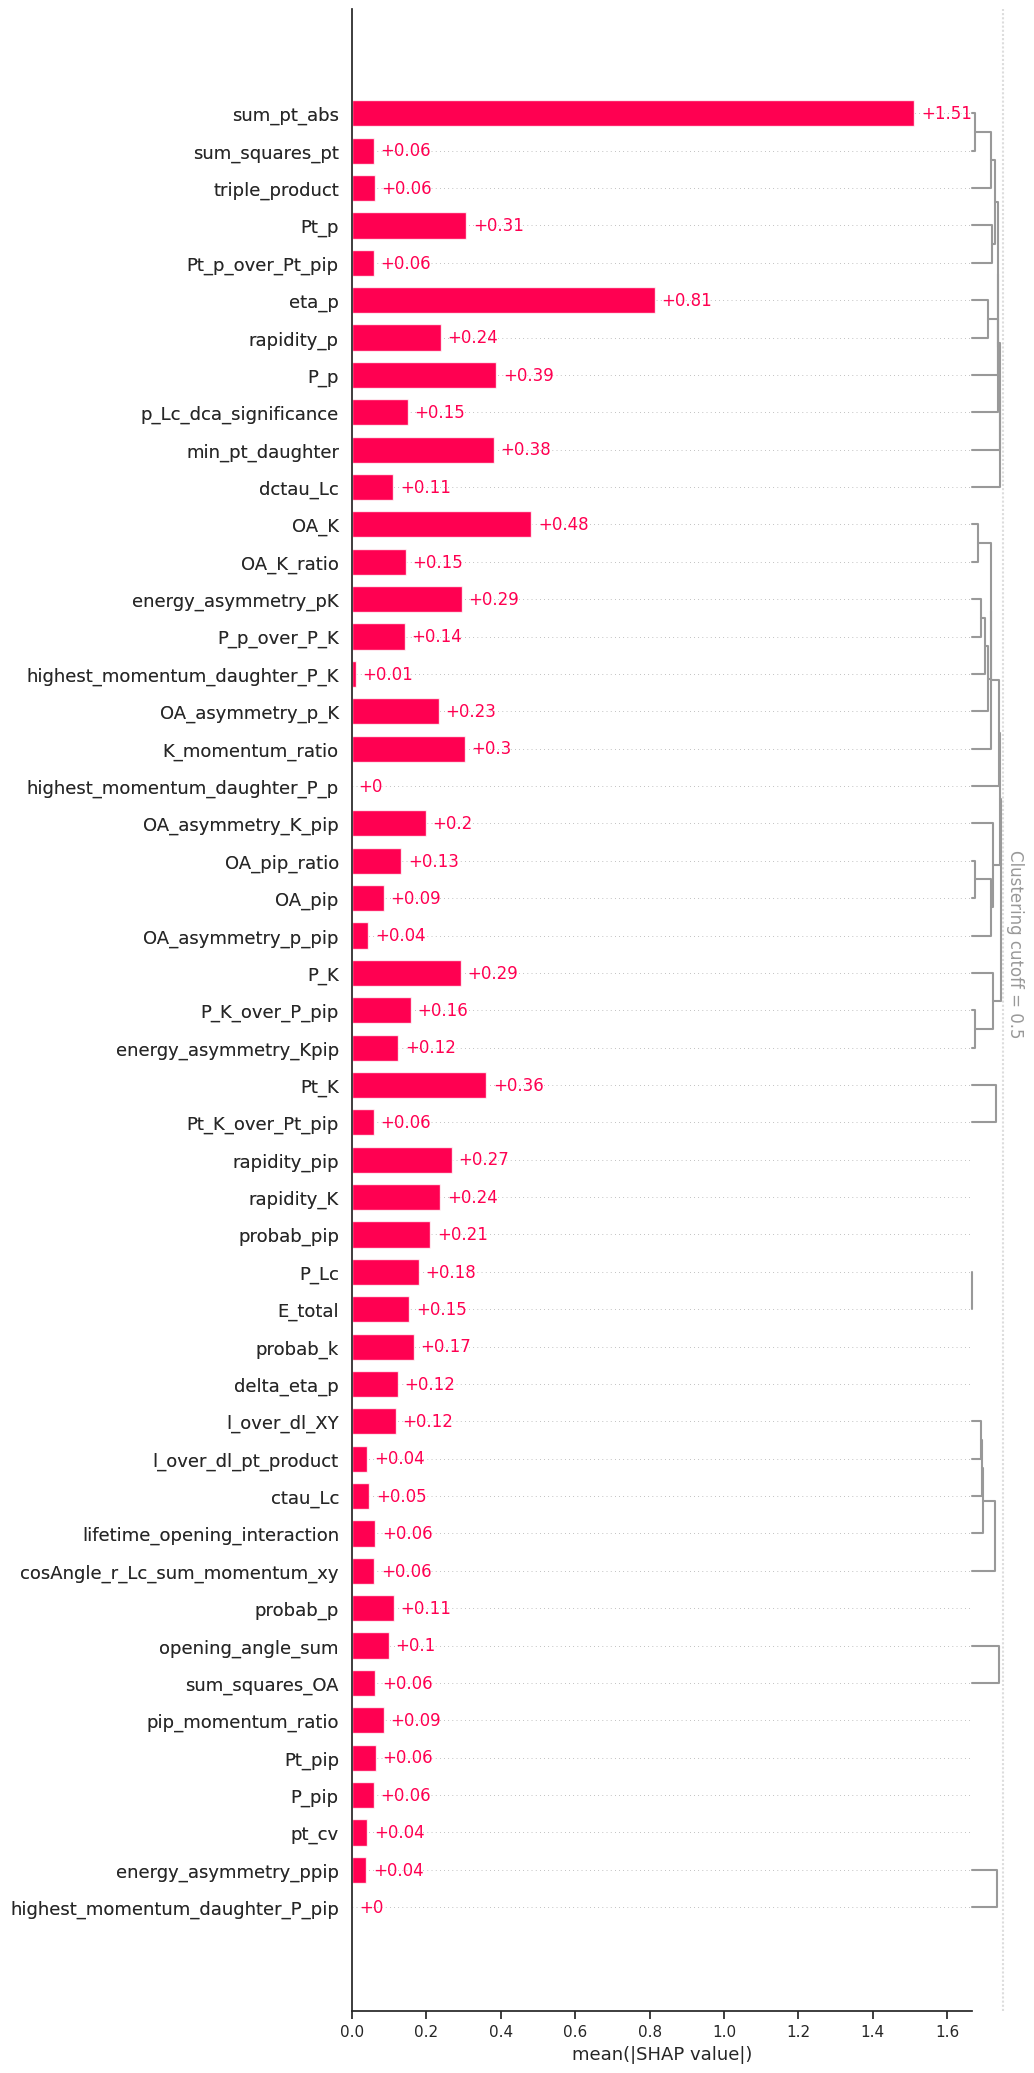

In [31]:
ax = shap.plots.bar(shap_values, clustering=clustering, clustering_cutoff=0.5, max_display=60, show=False)
ax.figure.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/shap_cluster.pdf', bbox_inches='tight')

<Figure size 600x600 with 0 Axes>

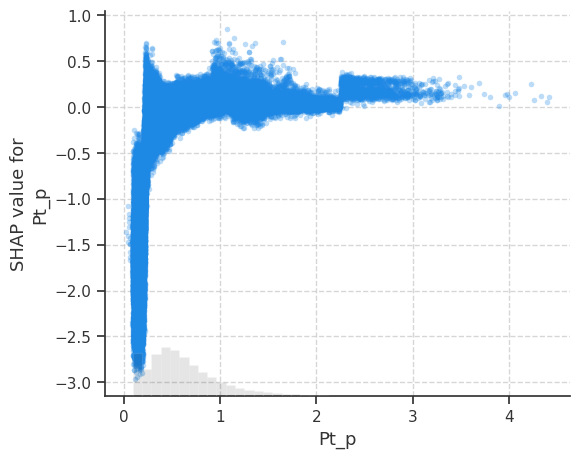

In [11]:
feature_name = 'Pt_p'

plt.figure(figsize=(6, 6))
ax = shap.plots.scatter(shap_values[:, feature_name], alpha=0.3, show=False)
ax.grid(True, alpha=0.8, linestyle='--')
ax.figure.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/shap_scatter_{feature_name}.pdf', bbox_inches='tight')

In [14]:
feature_name = 'Pt_p'

plt.figure(figsize=(6, 6))
ax = shap.plots.waterfall(shap_values[4], show=False)
ax.grid(True, alpha=0.8, linestyle='--')
ax.figure.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/shap_waterfall_{4}.pdf', bbox_inches='tight')

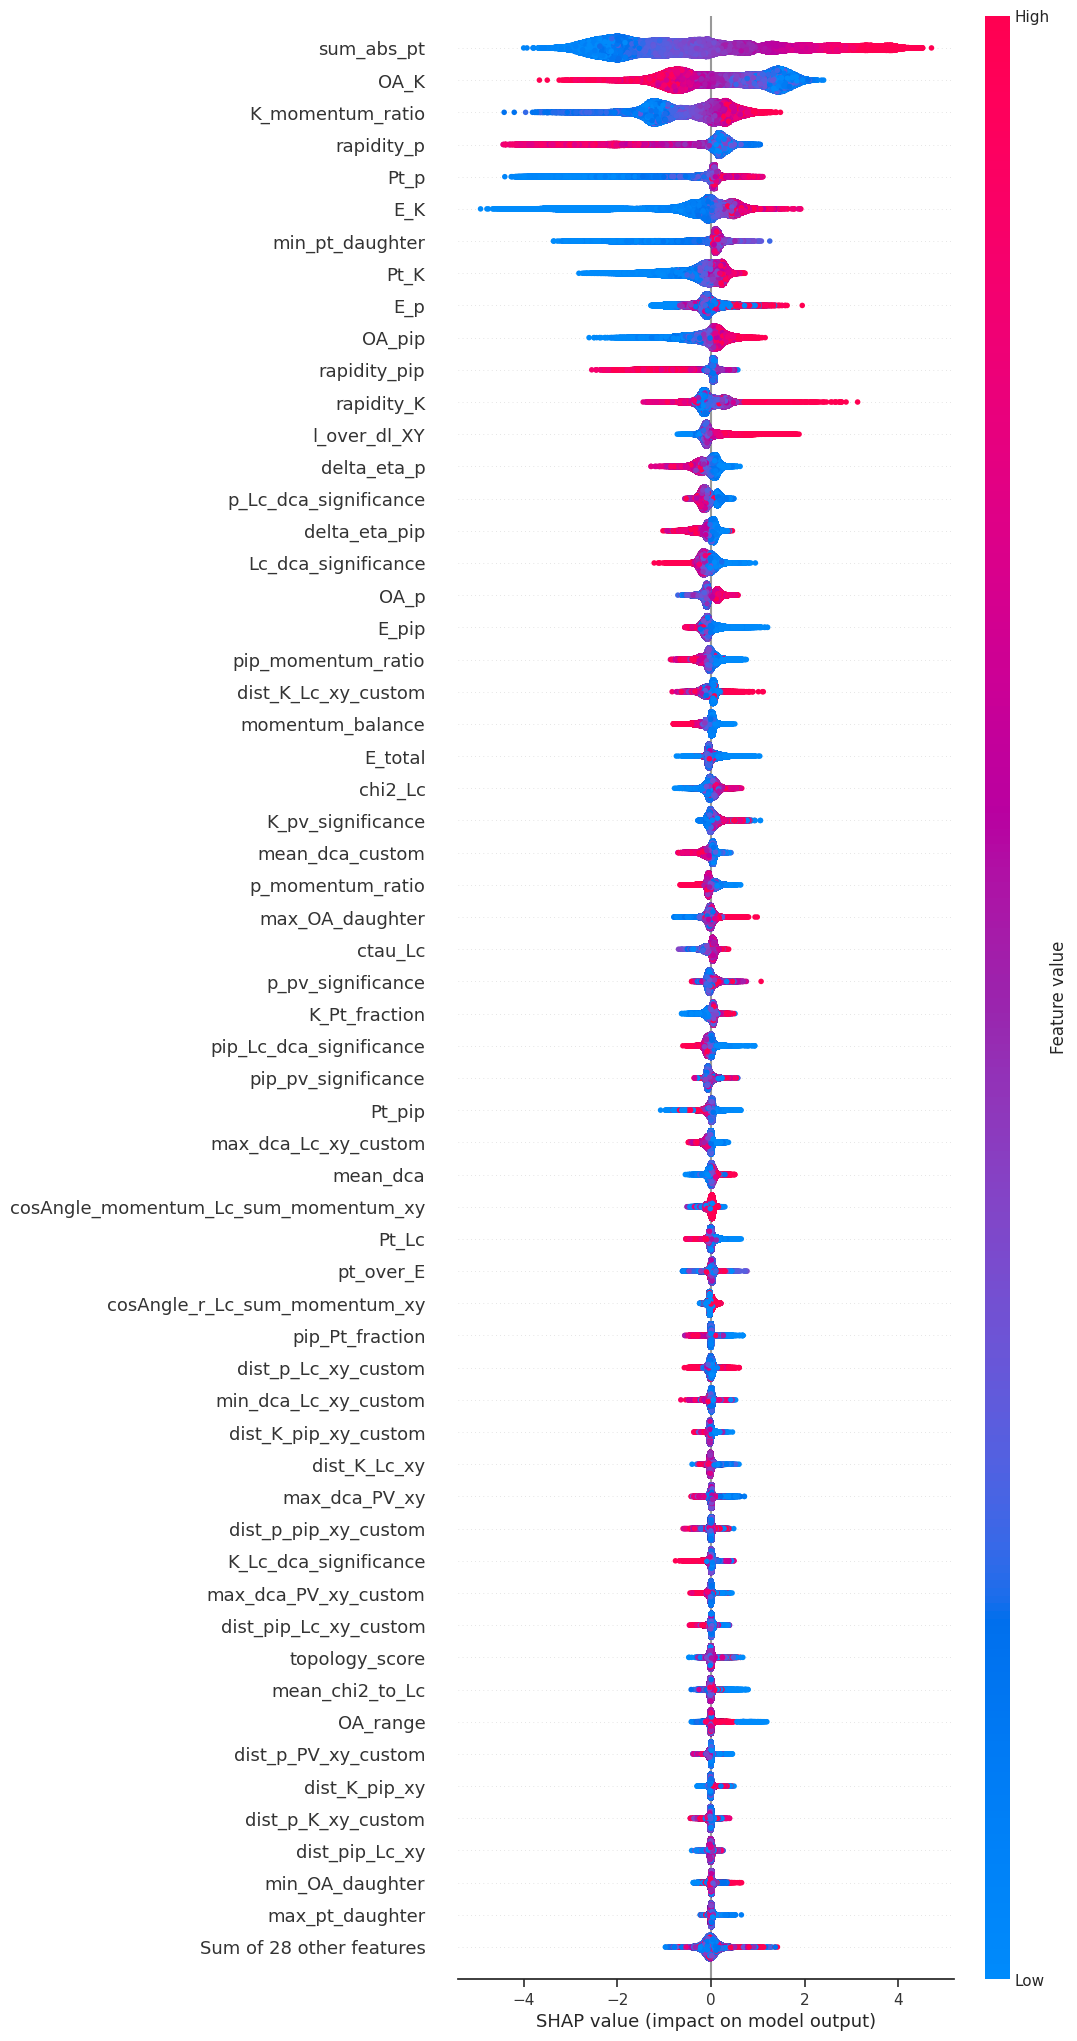

In [10]:
# shap.plots.beeswarm(shap_values, max_display=60, order=shap_values.abs.mean(0))
plt.figure(figsize=(6, 6))
ax = shap.plots.beeswarm(shap_values, max_display=60, order=shap_values.abs.mean(0), show=False)
ax.figure.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/_cut_based_low_corr_selection_shap_beeswarm.pdf', bbox_inches='tight')

### RFE

In [ ]:
from sklearn.feature_selection import RFECV


params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256, 
    # 'scale_pos_weight': len(y_train[y_train == 0]) / len(y_train[y_train == 1])
})

estimator = XGBClassifier(**params)

selector = RFECV(
    estimator, 
    step=1, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=6,
    verbose=1,
)

selector = selector.fit(x_train, y_train)

mean_scores = selector.cv_results_['mean_test_score']
std_scores = selector.cv_results_['std_test_score']

optimal_score = np.max(mean_scores)
optimal_idx = np.argmax(mean_scores)

print("Optimal number of features:", selector.n_features_)
print(f"Best score: {optimal_score:.4f}")
print("Selected features:")
for feat in x_train.columns[selector.support_]:
    print(f"  - {feat}")

# Plot RFE
plt.figure(figsize=(14, 8))

n_features_range = range(selector.min_features_to_select, 
                        len(mean_scores) + selector.min_features_to_select)

df_scores = pd.DataFrame({
    'Number of Features': n_features_range,
    'Mean Score': mean_scores,
    'Std Score': std_scores
})

confidence_multiplier = 1.96
df_scores['Upper_CI'] = df_scores['Mean Score'] + confidence_multiplier * df_scores['Std Score']
df_scores['Lower_CI'] = df_scores['Mean Score'] - confidence_multiplier * df_scores['Std Score']


plt.fill_between(df_scores['Number of Features'], 
                df_scores['Lower_CI'], 
                df_scores['Upper_CI'], 
                alpha=0.3, 
                color='steelblue',
                label='95% Confidence Interval')

line_plot = sns.lineplot(data=df_scores, 
                        x='Number of Features', 
                        y='Mean Score',
                        marker='o',
                        linewidth=2.5,
                        markersize=8,
                        color='steelblue',
                        label='Mean Score')

optimal_features = selector.n_features_
plt.axvline(x=optimal_features, color='red', linestyle='--', alpha=0.7, 
            linewidth=2, label=f'Optimal: {optimal_features} features')

optimal_point = plt.scatter(optimal_features, optimal_score, 
                        color='red', s=200, zorder=5, 
                        label=f'Optimal Score: {optimal_score:.4f}',
                        edgecolors='black', linewidth=2)


plt.title('RFECV Performance: Score vs Number of Features\n(with 95% Confidence Intervals)', 
        fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Features', fontsize=12, fontweight='bold')
plt.ylabel('Mean ROC-AUC Score', fontsize=12, fontweight='bold')
plt.xticks(list(n_features_range))
plt.grid(True, alpha=0.3)
plt.legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("Results (Mean +- 1.96*Std for 95% CI):")
print("="*60)

for i, (n_feat, mean_score, std_score) in enumerate(zip(n_features_range, mean_scores, std_scores)):
    ci_lower = mean_score - 1.96 * std_score
    ci_upper = mean_score + 1.96 * std_score
    marker = " ← OPTIMAL" if n_feat == optimal_features else ""
    print(f"Features: {n_feat:2d} | Score: {mean_score:.4f} | "
        f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]{marker}")

print("="*60)

plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/xgboost_RFE.pdf', bbox_inches='tight')

### Cross-validation

In [30]:
params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256, 
})

try:
    experiment.log_parameters(params)
except NameError:
    pass

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
split_generator = skf.split(x_train, y_train)

train_scores = []
val_scores = []
for fold, (train_idx, val_idx) in enumerate(split_generator):
    
    fold_x_train = x_train.iloc[train_idx, :]
    fold_y_train = y_train.iloc[train_idx]
    fold_x_val = x_train.iloc[val_idx, :]
    fold_y_val = y_train.iloc[val_idx]
    
    fold_model = XGBClassifier(**params)
    
    fold_model.fit(
        fold_x_train, 
        fold_y_train,
        eval_set=[(fold_x_train, fold_y_train), (fold_x_val, fold_y_val)],
        verbose=0
    )
    
    fold_train_pred_proba = fold_model.predict_proba(fold_x_train)[:, 1]
    fold_val_pred_proba = fold_model.predict_proba(fold_x_val)[:, 1]
    
    fold_train_score = roc_auc_score(fold_y_train, fold_train_pred_proba)
    fold_val_score = roc_auc_score(fold_y_val, fold_val_pred_proba)
    
    train_scores.append(fold_train_score)
    val_scores.append(fold_val_score)

    print(f'\nFold {fold} result:  train score: {fold_train_score:0.3f}, val score: {fold_val_score: 0.3f}\n')


train_scores = np.array(train_scores)
val_scores = np.array(val_scores)

try:
    experiment.log_metrics({
        'cv_train_mean_roc_auc':  train_scores.mean(),
        'cv_val_mean_roc_auc':  val_scores.mean()
    })
except NameError:
    pass

print(f'\n\nMean CV train score: {train_scores.mean():0.3f}')
print(f'Mean CV val score: {val_scores.mean():0.3f}')


Fold 0 result:  train score: 0.984, val score:  0.977


Fold 1 result:  train score: 0.984, val score:  0.978


Fold 2 result:  train score: 0.984, val score:  0.977


Fold 3 result:  train score: 0.984, val score:  0.977


Fold 4 result:  train score: 0.984, val score:  0.977



Mean CV train score: 0.984
Mean CV val score: 0.977


### Single Model Estimation

#### Create model

In [8]:
params = {}
params.update({
    'booster': 'gbtree',
    'grow_policy': 'depthwise',
    'tree_method': 'hist',
    'random_state': CFG.seed,
    'eval_metric': 'auc',
    'verbosity': 0,
    'device': 'cuda' if CFG.gpu_available else 'cpu',
    'n_jobs': 1 if CFG.gpu_available else 6,
    'max_bin': 256,
})

model = XGBClassifier(**params)
model.fit(
    x_train, 
    y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=0
)

# Evaluate on train set
y_pred_train = np.where(model.predict_proba(x_train)[:, 1] > 0.5, 1, 0)
y_pred_proba_train = model.predict_proba(x_train)[:, 1]

print(f'\n{'#'*60}')
print(f"Train set performance:\n")
print(classification_report(y_true=y_train, y_pred=y_pred_train))
print(f"ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_train, y_pred_proba_train))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_train, y_pred_proba_train))
except NameError:
    pass

# Evaluate on val set
y_pred_val = np.where(model.predict_proba(x_val)[:, 1] > 0.5, 1, 0)
y_pred_proba_val = model.predict_proba(x_val)[:, 1]

print(f'\n{'#'*60}')
print(f"Val set performance:\n")
print(classification_report(y_true=y_val, y_pred=y_pred_val))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_val):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_val, y_pred_proba_val))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_val, y_pred_proba_val))
except NameError:
    pass

# Evaluate on test set
y_pred_test = np.where(model.predict_proba(x_test)[:, 1] > 0.5, 1, 0)
y_pred_proba_test = model.predict_proba(x_test)[:, 1]

print(f'\n{'#'*60}')
print(f"Test set performance:\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_test, y_pred_proba_test))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_test, y_pred_proba_test))
except NameError:
    pass


############################################################
Train set performance:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96    283843
           1       0.86      0.86      0.86     77664

    accuracy                           0.94    361507
   macro avg       0.91      0.91      0.91    361507
weighted avg       0.94      0.94      0.94    361507

ROC-AUC: 0.9834

############################################################
Val set performance:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     70961
           1       0.84      0.84      0.84     19416

    accuracy                           0.93     90377
   macro avg       0.90      0.90      0.90     90377
weighted avg       0.93      0.93      0.93     90377

ROC-AUC: 0.9775

############################################################
Test set performance:

              precision    recall  f1-score   support

    

#### Classifier Calibration

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


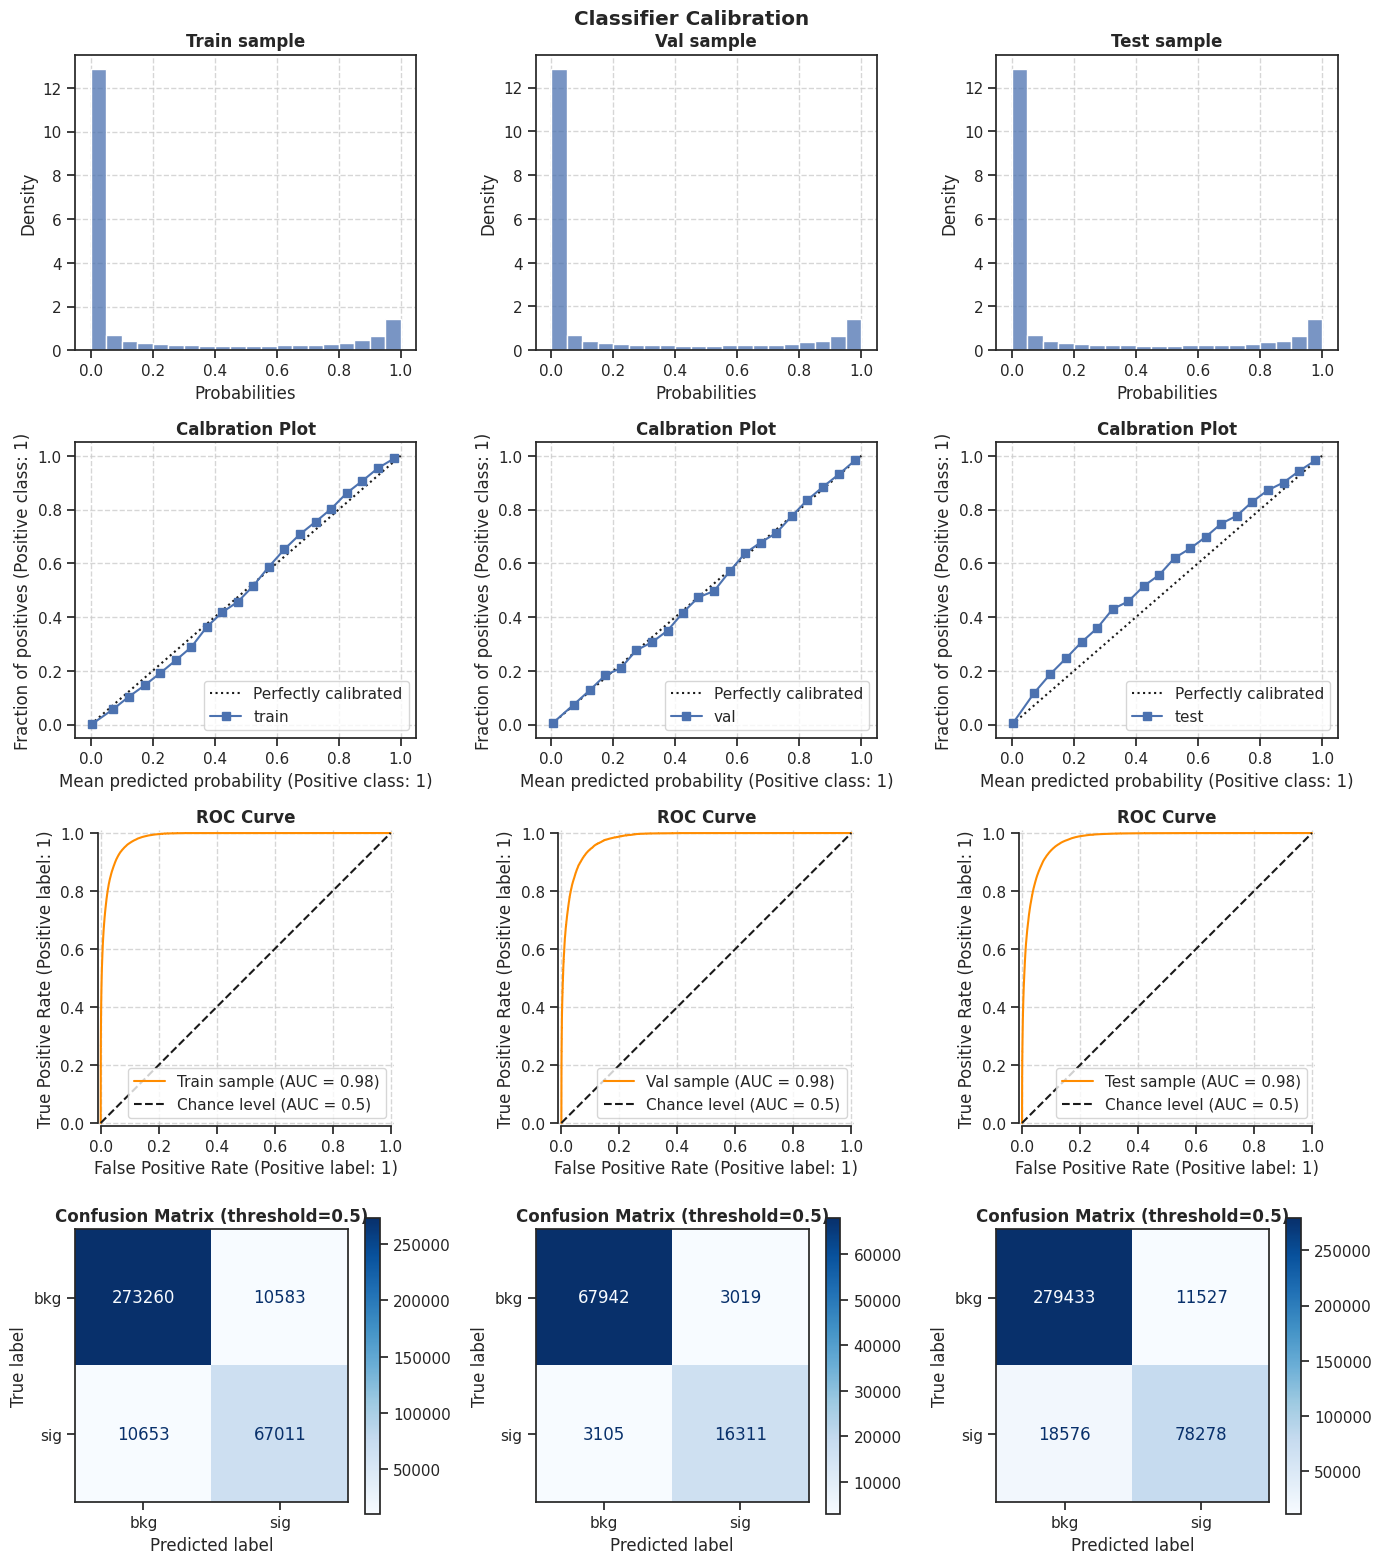

In [9]:
n_bins=20

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 16))
fig.suptitle('Classifier Calibration', fontweight='bold')

#######################################
sns.histplot(
    data=y_pred_proba_train,
    stat='density',
    bins=n_bins,
    ax=axes[0][0]
)

axes[0][0].set_title('Train sample', fontweight='bold')
axes[0][0].set_xlabel('Probabilities')
axes[0][0].set_ylabel('Density')
axes[0][0].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_train, y_pred_proba_train, name='train', n_bins=n_bins, ax=axes[1][0])

axes[1][0].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][0].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_pred_proba_train,
    name=f"Train sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][0]
)

axes[2][0].set_title('ROC Curve', fontweight='bold')
axes[2][0].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_train, 
    y_pred=y_pred_train,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][0]
)

axes[3][0].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][1]
)

axes[0][1].set_title('Val sample', fontweight='bold')
axes[0][1].set_xlabel('Probabilities')
axes[0][1].set_ylabel('Density')
axes[0][1].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_val, y_pred_proba_val, name='val', n_bins=n_bins, ax=axes[1][1])

axes[1][1].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][1].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_pred_proba_val,
    name=f"Val sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][1]
)

axes[2][1].set_title('ROC Curve', fontweight='bold')
axes[2][1].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_val, 
    y_pred=y_pred_val,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][1]
)

axes[3][1].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][2]
)

axes[0][2].set_title('Test sample', fontweight='bold')
axes[0][2].set_xlabel('Probabilities')
axes[0][2].set_ylabel('Density')
axes[0][2].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_test, y_pred_proba_test, name='test', n_bins=n_bins, ax=axes[1][2])

axes[1][2].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][2].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_proba_test,
    name=f"Test sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][2]
)

axes[2][2].set_title('ROC Curve', fontweight='bold')
axes[2][2].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=y_pred_test,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][2]
)

axes[3][2].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
plt.tight_layout()

try:
    experiment.log_figure(
        figure_name=f"Calibration plots",
        figure=plt.gcf()
    )
except NameError:
    pass

fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/calibration_plot_1.pdf', bbox_inches='tight')
plt.show()

#### Optimize threshold (validation sample)

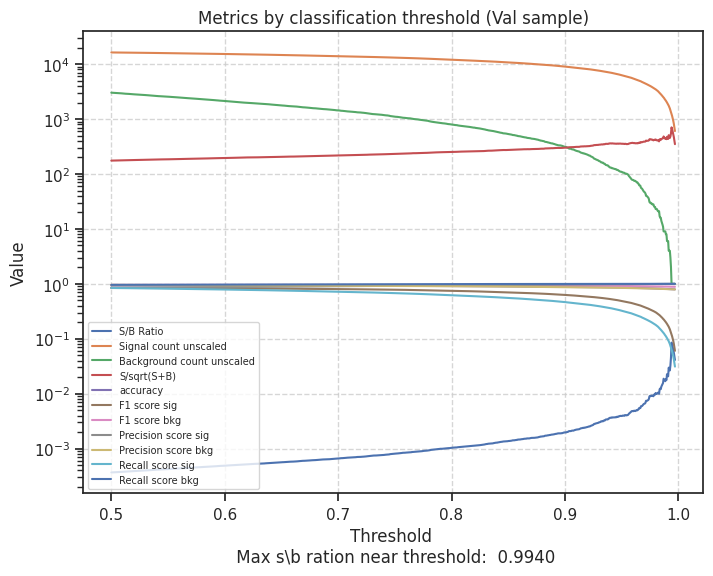

In [10]:
thresholds = []
sig_events_number_list = []
bkg_events_number_list = []
s_over_b = []
significance_list = []
acc_list = []
f1_sig_list = []
f1_bkg_list = []
prec_sig_list = []
prec_bkg_list = []
rec_sig_list = []
rec_bkg_list = []

for threshold in np.arange(0.5, 1, 0.0005):
    
    signal_counts_after = ((y_val) & (y_pred_proba_val >= threshold)).sum()
    signal_counts_before = y_val.sum()
    background_counts_after = ((~y_val.astype(bool)) & (y_pred_proba_val >= threshold)).sum()
    background_counts_before = (~y_val.astype(bool)).sum()

    if not signal_counts_after or not background_counts_after:
        break

    signal_eff_ML = signal_counts_after / signal_counts_before
    background_eff_ML = background_counts_after / background_counts_before

    sig_mass_distr = train_df.loc[train_df['tag'] == 'Sig', 'mass_Lc']
    bg_mass_distr = train_df.loc[train_df['tag'] == 'Bg', 'mass_Lc']

    overall_s_b, significance, *_ = signal_estimates(
        sig_mass_distr=sig_mass_distr,
        bg_mass_distr=bg_mass_distr,
        have_sig_events=CFG.have_sig_events_2 * 0.2 / signal_eff_ML,    # 0.2 is val_fraction in train dataset
        have_bg_events=CFG.have_bg_events_2 * 0.2 / background_eff_ML,
        mass_interval=CFG.mass_interval,
        visualization=False,
        verbose=False
    )
    
    f1_sig = f1_score(y_val, np.where(model.predict_proba(x_val)[:, 1] > threshold, 1, 0))
    f1_bkg = f1_score(1 - y_val, np.where(model.predict_proba(x_val)[:, 1] < threshold, 1, 0))
    acc = accuracy_score(y_val, np.where(model.predict_proba(x_val)[:, 1] > threshold, 1, 0))
    prec_sig = precision_score(y_val, np.where(model.predict_proba(x_val)[:, 1] > threshold, 1, 0))
    prec_bkg = precision_score(1 - y_val, np.where(model.predict_proba(x_val)[:, 1] < threshold, 1, 0))
    rec_sig = recall_score(y_val, np.where(model.predict_proba(x_val)[:, 1] > threshold, 1, 0))
    rec_bkg = recall_score(1 - y_val, np.where(model.predict_proba(x_val)[:, 1] < threshold, 1, 0))
    
    f1_sig_list.append(f1_sig)
    f1_bkg_list.append(f1_bkg)
    
    acc_list.append(acc)
    
    prec_sig_list.append(prec_sig)
    prec_bkg_list.append(prec_bkg)
    
    rec_sig_list.append(rec_sig)
    rec_bkg_list.append(rec_bkg)
    
    sig_events_number_list.append(signal_counts_after)
    bkg_events_number_list.append(background_counts_after)
    s_over_b.append(overall_s_b)
    significance_list.append(significance)
    thresholds.append(threshold)


res_df = pd.DataFrame({
    'threshold': thresholds,
    'sig_count': sig_events_number_list,
    'bkg_count': bkg_events_number_list,
    's_over_b': s_over_b,
    'significance': significance_list,
    'f1_sig': f1_sig_list,
    'f1_bkg': f1_bkg_list,
    'acc': acc_list,
    'prec_sig': prec_sig_list,
    'prec_bkg': prec_bkg_list,
    'rec_sig': rec_sig_list,
    'rec_bkg': rec_bkg_list,
})

fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(
    data=res_df,
    x='threshold',
    y='s_over_b',
    label='S/B Ratio',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='sig_count',
    label='Signal count unscaled',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='bkg_count',
    label='Background count unscaled',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='significance',
    label='S/sqrt(S+B)',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='acc',
    label='accuracy',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='f1_sig',
    label='F1 score sig',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='f1_bkg',
    label='F1 score bkg',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='prec_sig',
    label='Precision score sig',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='prec_bkg',
    label='Precision score bkg',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='rec_sig',
    label='Recall score sig',
    ax=ax,
)

sns.lineplot(
    data=res_df,
    x='threshold',
    y='rec_bkg',
    label='Recall score bkg',
    ax=ax,
)

ax.set_title('Metrics by classification threshold (Val sample)')
ax.set_xlabel(f'Threshold \n Max s\\b ration near threshold: {res_df.iloc[res_df['s_over_b'].idxmax()]['threshold']: .4f}')
ax.set_ylabel('Value')
ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend(prop={'size': 7})
fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/s_over_b_from_threshold.pdf', bbox_inches='tight')
plt.show()

In [11]:
optimal_threshold = 0.9936

signal_counts_after = ((y_val) & (y_pred_proba_val >= optimal_threshold)).sum()
background_counts_after = ((~y_val.astype(bool)) & (y_pred_proba_val >= optimal_threshold)).sum()
print(f'{signal_counts_after=}')
print(f'{background_counts_after=}')

signal_counts_after=np.int64(1327)
background_counts_after=np.int64(1)


#### Physics Evaluation (Test sample)

In [12]:
cut_based_selection_mask_test = np.where(y_pred_proba_test >= optimal_threshold, True, False)
cut_based_selection_mask_train = np.where(y_pred_proba_train >= optimal_threshold, True, False)

#### Background shape check (Test sample)

KS-test: distributions are identical, (alpha=0.05, p_value=0.793)


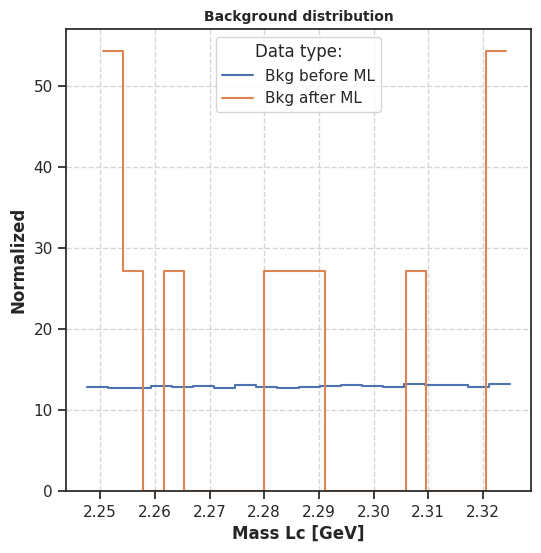

In [13]:
threshold = optimal_threshold
alpha = 0.05

df = x_test_full[['mass_Lc']].copy()
df['y_true'] = y_test
df['y_pred_proba'] = y_pred_proba_test

bkg_before_ML = df.loc[df.y_true == 0, 'mass_Lc']
bkg_after_Ml = df.loc[(df.y_pred_proba >= threshold) & (df.y_true == 0), 'mass_Lc']

# kolmogorov-Smirnov test
ks_stat, p_value = stats.ks_2samp(bkg_before_ML, bkg_after_Ml, alternative='two-sided')

try:
    experiment.log_metric(name='KS-test p-value', value=p_value)
except NameError:
    pass

if p_value >= alpha:
    print(f'KS-test: distributions are identical, ({alpha=}, {p_value=:0.3f})')
else:
    print(f'KS-test: distributions are different, ({alpha=}, {p_value=:0.3f})')


fig, ax = plt.subplots(figsize=(6, 6))

sns.histplot(
    data=bkg_before_ML,
    label='Bkg before ML',
    element='step',
    fill=False,
    stat='density',
    bins=20,
    # alpha=0.8,
    ax=ax
)

sns.histplot(
    data=bkg_after_Ml,
    label='Bkg after ML',
    element='step',
    fill=False,
    stat='density',
    bins=20,
    # alpha=0.8,
    ax=ax
)

plt.legend(title="Data type:", loc= "best")

ax.set_title('Background distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('Mass Lc [GeV]', fontweight='bold')
ax.set_ylabel('Normalized', fontweight='bold')
ax.grid(True, alpha=0.8, linestyle='--')

try:
    experiment.log_figure(
        figure_name=f"Bkg distr ML",
        figure=plt.gcf()
    )
except NameError:
    pass

fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/bkg_shape_09936.pdf', bbox_inches='tight')
plt.show()

# Cut-based ending (currently disabled)

## Get ML-handled data

In [25]:
y_pred_val = np.where(y_pred_proba_val >= optimal_threshold, 1, 0) 

df = x_val_full.copy()
df['tag'] = y_val.map({1: 'Sig', 0: 'Bg'})
df['pred_tag'] = y_pred_val.copy()

init_bkg_distr = df.loc[df['tag'] == 'Bg', 'mass_Lc'].copy()

df = df[df['pred_tag'] == 1]

## Selection Path Setup

In [ ]:
result_df = create_best_selection_path(
    df=df,
    features=CFG.feature_cut_based_sel,
    n_features_to_use=None,
    metric_type='tpr_fpr',
    have_sig_events=1,
    have_bg_events=1,
    mass_interval=CFG.mass_interval,
    direction_restrictions=CFG.cut_based_sel_restriction,
    nbins=1000,
)

In [ ]:
result_df

## Selection Var 1

In [ ]:
cut_based_sig_efficiency = 1
cut_based_bg_suppression = 1

cut_based_selection_mask_train = np.ones(df.shape[0], dtype=bool)

df_copy = df.copy()

### Cut 1: sum_pt_abs

In [ ]:
feature = 'sum_pt_abs'
select_direction = 'right'
metric_type = 'tpr_fpr'
bounds = None
min_sig_sel = 0.3

num_sig_before_sel = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count()
num_bg_before_sel = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count()

min_sig_sel_mask, best_arg, metric, thresholds, tpr, fpr, sig_efficiency, bg_efficiency = find_optimal_cut_point(
    df=df[['mass_Lc', 'tag', feature]],
    feature=feature,
    bounds=bounds,
    nbins=1000,
    select_direction=select_direction,
    metric_type=metric_type,
    min_sig_sel=min_sig_sel,
    mass_interval=CFG.mass_interval
)

if bounds is not None:
    bounds_mask = (df[feature] >= bounds[0]) & (df[feature] <= bounds[1])
    df = df[bounds_mask]
    
best_cut_x = thresholds[min_sig_sel_mask][best_arg]
best_metric = metric[min_sig_sel_mask][best_arg]
best_tpr = tpr[min_sig_sel_mask][best_arg]
best_fpr = fpr[min_sig_sel_mask][best_arg]

#--------------------------------------------------
# # Manual cut
# best_cut_x = 1.1758495257275554
# 
# # find index by value
# val = best_cut_x
# arr = thresholds[min_sig_sel_mask]
# 
# diff = abs(arr - val)
# index = np.argmin(diff)
#     
# best_tpr = tpr[min_sig_sel_mask][index]
# best_fpr = fpr[min_sig_sel_mask][index]
#--------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
draw_feature_distribution(
    df=df,
    distr_name=feature,
    tag=None,
    axes=[axes[0], axes[1]],
    hue='tag',
    bins=40,
    norma=True,
    cut_point=best_cut_x,
    select_direction=select_direction
)

_ = draw_roc(
        tpr=tpr,
        fpr=fpr,
        ax=axes[2],
        best_cut_x=best_cut_x,
        best_tpr=best_tpr,
        best_fpr=best_fpr,
        select_direction=select_direction,
        mask=min_sig_sel_mask,
        min_sig_sel=min_sig_sel
    )

# Mask 
if select_direction == 'right':
    mask = df[feature] > best_cut_x
    general_mask_train = df_copy[feature] > best_cut_x
    general_mask_test = test_df[feature] > best_cut_x
else:
    mask = df[feature] < best_cut_x
    general_mask_train = df_copy[feature] < best_cut_x
    general_mask_test = test_df[feature] < best_cut_x

df = df[mask]
cut_based_selection_mask_train &= general_mask_train
cut_based_selection_mask_test &= general_mask_test

print(f'Cut point: {best_cut_x}')

sig_eff = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count() / num_sig_before_sel
bg_eff = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count() / num_bg_before_sel

total_sig_efficiency *= sig_eff
total_bg_suppression *= bg_eff

print(f'Signal efficiency: {sig_eff}')
print(f'Background Suppression: {bg_eff}')

sns.histplot(
    data=df.loc[df['tag'] == 'Bg', 'mass_Lc'],
    label='Bkg distr',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

sns.histplot(
    data=init_bkg_distr,
    label='Init Bkg distr',
    linestyle='--',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

plt.legend(loc= "best", fontsize=8)

axes[3].set_title('Background distribution', fontsize=8)
axes[3].set_xlabel('Mass Lc [GeV]', fontsize=8)
axes[3].set_ylabel('Normalized', fontsize=8)
axes[3].tick_params(axis='both', which='major', labelsize=5)
axes[3].grid(True, alpha=0.8, linestyle='--')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{feature}_cut_after_ML.pdf', bbox_inches='tight')

# Data Stats After Selection

In [19]:
temp_train_df = x_train.copy()
temp_train_df['tag'] = y_train.copy()
temp_train_df['cut_based_selection_mask_train'] = cut_based_selection_mask_train
temp_train_df = temp_train_df.rename(columns={'cut_based_selection_mask_train': 'selected'})

temp_test_df = test_df.copy()
temp_test_df['cut_based_selection_mask_test'] = cut_based_selection_mask_test
temp_test_df = temp_test_df.rename(columns={'cut_based_selection_mask_test': 'selected'})

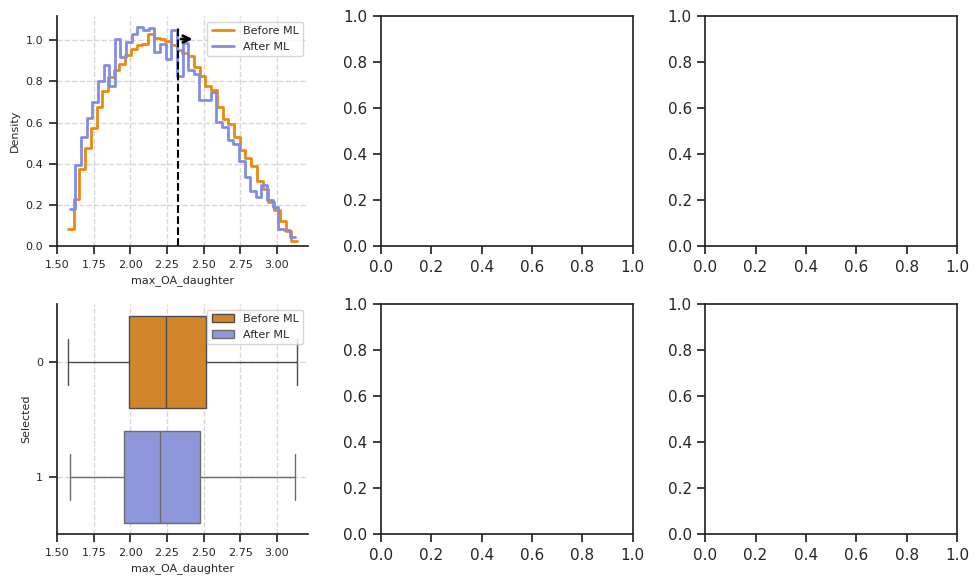

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

names = (
    'max_OA_daughter',
)

select_direction = ['right',]
cut_point = [2.3260215907687654,]

for i, (distr_name, ax) in enumerate(zip(names, axes[0, :])):
    sns.histplot(
        data=temp_test_df.loc[temp_test_df['tag'] == 'Sig'],
        x=distr_name,
        color="#EC8910",
        alpha=1,
        element='step',
        stat="density",
        common_norm=False,
        fill=False,
        linewidth=2,
        bins=40,
        ax=ax,
        label='Before ML'
    )
    
    sns.histplot(
        data=temp_test_df.loc[(temp_test_df['tag'] == 'Sig') & (temp_test_df['selected'] == 1)],
        x=distr_name,
        color="#828EE5",
        alpha=1,
        element='step',
        stat="density",
        common_norm=False,
        fill=False,
        linewidth=2,
        bins=40,
        ax=ax,
        label='After ML',
    )
    
    ax.set_xlabel(f'{distr_name}', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.8, linestyle='--')
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(loc='upper right', fontsize=8)
    
    y_min, y_max = ax.get_ylim()
    ax.axvline(cut_point[i], color='black', linestyle='dashed', 
                    linewidth=1.5, ymin=0, ymax=0.95)

    arrow_y_pos = y_max * 0.9    
    data = temp_test_df[distr_name].dropna()
    counts, bin_edges = np.histogram(data, bins=40)
    bin_width = bin_edges[1] - bin_edges[0]

    if select_direction[i] == 'right':
        arrow_direction = cut_point[i] + bin_width * 3
    else:
        arrow_direction = cut_point[i] - bin_width * 3
        
    ax.annotate(
        '', 
        xy=(cut_point[i], arrow_y_pos), 
        xytext=(arrow_direction, arrow_y_pos),
        arrowprops=dict(arrowstyle='<-', color='black', lw=2)
    )

for i, (distr_name, ax) in enumerate(zip(names, axes[1, :])):
    
    sns.boxplot(
        data=temp_test_df.loc[temp_test_df['tag'] == 'Sig'],
        x=distr_name,
        y=[0] * len(temp_test_df.loc[temp_test_df['tag'] == 'Sig']),
        color="#EC8910",
        orient='h',
        whis=1.5,
        ax=ax,
        dodge=False,
        label='Before ML'
    )
    
    sns.boxplot(
        data=temp_test_df.loc[(temp_test_df['tag'] == 'Sig') & (temp_test_df['selected'] == 1)],
        x=distr_name,
        y=[1] * len(temp_test_df.loc[(temp_test_df['tag'] == 'Sig') & (temp_test_df['selected'] == 1)]),
        color="#828EE5",
        orient='h',
        whis=1.5,
        ax=ax,
        dodge=False,
        label='After ML'
    )
    
    ax.set_xlabel(f'{distr_name}', fontsize=8)
    ax.set_ylabel('Selected', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.8, linestyle='--')
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(loc='upper right', fontsize=8)


plt.tight_layout()
plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/dist_after_ML_4.pdf', bbox_inches='tight')
plt.show()

``s/b uncertanty calculate with true selected data as it demands numbers of events per bin after selection``


SUMMARY STATISTICS
Total Signal Events: 1063732
Total Background Events: 30307739
Total Signal Events Unscaled: 5211
Total Background Events Unscaled: 10
Overall S/B Ratio: 0.035098
s_b_uncertainty: 0.016788652071757944
Overall S/sqrt(S+B) Significance: 189.92


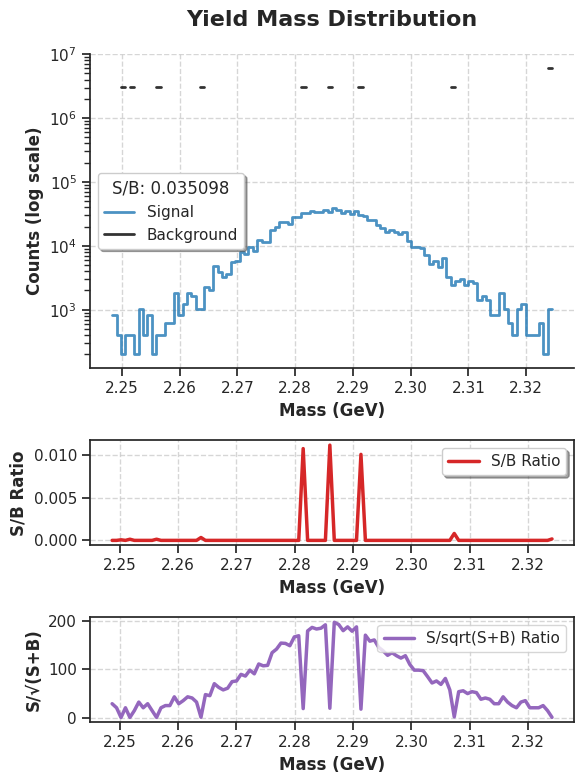

In [21]:
# Selected data
sig_mass_distr = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Sig'), 'mass_Lc']
bg_mass_distr = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Bg'), 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr,
    have_sig_events=CFG.have_sig_events_1,
    have_bg_events=CFG.have_bg_events_1,
    mass_interval=CFG.mass_interval, 
    visualization=True,
    verbose=True,
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/mass_stats_after_selection_ML_based_true_var_1.pdf')

### Train

In [27]:
sig_before_sel_train = temp_train_df.loc[temp_train_df['tag'] == 1, 'tag'].count()
bg_before_sel_train = temp_train_df.loc[temp_train_df['tag'] == 0, 'tag'].count()
sig_after_sel_train = temp_train_df.loc[cut_based_selection_mask_train & (temp_train_df['tag'] == 1), 'tag'].count()
bg_after_sel_train = temp_train_df.loc[cut_based_selection_mask_train & (temp_train_df['tag'] == 0), 'tag'].count()

sig_efficiency_train = sig_after_sel_train / sig_before_sel_train
bg_efficiency_train = bg_after_sel_train / bg_before_sel_train

print(f'sig_efficiency: {sig_efficiency_train}')
print(f'bg_efficiency: {bg_efficiency_train}')

sig_efficiency: 0.0679465389369592
bg_efficiency: 3.5230743756231436e-06


### Test

In [28]:
sig_before_sel = test_df.loc[test_df['tag'] == 'Sig', 'tag'].count()
bg_before_sel = test_df.loc[test_df['tag'] == 'Bg', 'tag'].count()
sig_after_sel = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Sig'), 'tag'].count()
bg_after_sel = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Bg'), 'tag'].count()

sig_efficiency = sig_after_sel / sig_before_sel
bg_efficiency = bg_after_sel / bg_before_sel

print(f'Signal efficiency: {sig_efficiency}')
print(f'Background efficiency: {bg_efficiency}')

total_signal_efficiency = CFG.sig_eff_presel * sig_efficiency
total_background_efficiency = CFG.bg_eff_presel * bg_efficiency

print(f'\nTotal signal efficiency (include presel): {total_signal_efficiency}')
print(f'Total background efficiency (include presel): {total_background_efficiency}')

Signal efficiency: 0.053802630763830094
Background efficiency: 3.436898542755018e-05

Total signal efficiency (include presel): 0.05096083321108992
Total background efficiency (include presel): 2.1310147892426374e-05



SUMMARY STATISTICS
Total Signal Events: 1063732
Total Background Events: 30307739
Total Signal Events Unscaled: 96854
Total Background Events Unscaled: 290960
Overall S/B Ratio: 0.035098
s_b_uncertainty: 0.00019684368406576268
Overall S/sqrt(S+B) Significance: 189.92


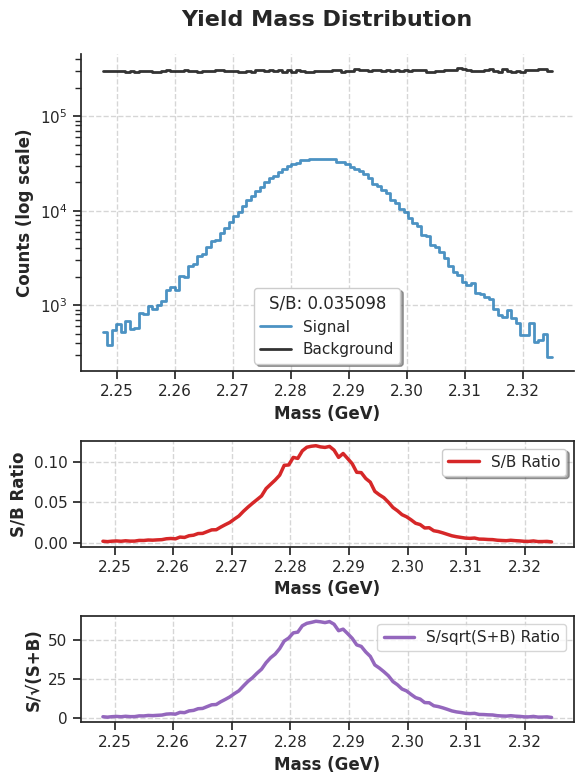

In [29]:
# Preselection stage data
sig_mass_distr = test_df.loc[test_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = test_df.loc[test_df['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_efficiency, # no need to divide by sig_eff_presel for preselection stage data!!
    have_bg_events=CFG.have_bg_events_1 / bg_efficiency,
    mass_interval=CFG.mass_interval, 
    visualization=True,
    verbose=True,
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/mass_stats_after_selection_ML.pdf', bbox_inches='tight')

# End experiment log

In [28]:
try:
    experiment.end()
except NameError:
    pass

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Feature set 9, params_xgboost_1
COMET INFO:     url                   : https://www.comet.com/artem-smirnov/spd-ml/0693236162e74333af60f28fd99668c9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     KS-test p-value          : 0.2063428319742281
COMET INFO:     accuracy_score_test      : 0.8630973158266878
COMET INFO:     accuracy_score_train     : 0.9340795004693303
COMET INFO:     accuracy_score_val       : 0.8816927848514529
COMET INFO:     background_eff_ML        : 0.1643822455645936
COMET INFO:     cv_train_mean_roc_auc    : 0.9860572800640174
COMET INFO:     cv_val_mean_roc_auc      : 0.9559364930000586
COMET INFO:     roc_auc_score_test